# Women’s Cricket World Cup Outcome Prediction

## Overview

This project aims to predict match outcomes for the **Women’s Cricket World Cup 2025**
using historical Women’s ODI (WODI) match data.

We extract raw ball-by-ball data from [Cricsheet](https://cricsheet.org/) to build a
**PostgreSQL relational database**, which serves as the primary source of data.
We then create match-level features from the database using SQL and Python, that we use to train and evaluate supervised machine learning models.

Details of the setup and data pipeline may be found in the [README](../README.md).

For convenience, we"ve stored snapshots of features and target datasets as CSV files in the directory `../data/processed/`.

## Problem Statement

Given match-level features derived from historical ball-by-ball data,
**can we predict the outcome of a Women’s Cricket World Cup match?**

This is formulated as a **supervised learning** problem:

* **Training data:** WODIs played before WC 2025
* **Evaluation data:** Matches from the Women’s Cricket World Cup 2025

![Workflow](https://mermaid.ink/svg/pako:eNpFj01rwzAMhv-K0WWXtCRuvpzDoE0PG6xsjEFhSQ9eoiSGxA62wz6a_ve52cZ0kuB9HklnqFSNkEHTq_eq49qSh-dSElfb4k4Yq7SoeE-Oj_t7Q96wURrJMac-jU5ktbqdXzQXUsiW1NzymeyKg_P1px_Fbok8aaxFZYWSZiZ5cVQDyhtDjkr3NcmnkVxt5MBt1aH5JfOFzNUwco0z2Rfbyk7ujmc0U2_NCTxotaghs3pCDwbUA7-OcL7yJdgOBywhc22NDXdMCaW8OGzk8lWp4Y_Uamo7yBreGzdNo3sD94K3mv9HUNaoczVJC1kQsMUB2Rk-INvQdbRJGA2YH0VBEqUefLpQmK5jGrI0TMKABj4LLx58LVv9NYtp5Pt-kLI4ZglNLt_KgHjC)

## Dataset

As mentioned above, snapshots of features and target datasets are stored locally. We now take a quick look at the dataset.

In [2]:
# Imports

from pathlib import Path
import pandas as pd

In [3]:
# File Paths

processed_datadir = Path("../data/processed/").resolve()
features_csv = processed_datadir / "features.csv"
target_csv = processed_datadir / "target.csv"

In [4]:
features = pd.read_csv(
    features_csv, parse_dates=["start_date"], index_col="match_id"
    )
target = pd.read_csv(target_csv, index_col="match_id")

In [5]:
features.tail()

,hash_id,start_date,team,opponent,home_advantage,chasing_advantage,delta_team_strength
match_id,,,,,,,
1490442,3a1eb3da638f66392455d1eaf8d23d32,2025-10-30,India,Australia,1,-0.54,-0.377715
1490443,f03dd0c2940b950d1668c6744d4a59bc,2025-11-02,India,South Africa,1,0.55,0.094586
1500387,2dda2509fe7e744b61b3404a34718818,2025-09-16,Pakistan,South Africa,1,0.45,-0.488456
1500388,1fb22dc2953abda69f517b600c07d91b,2025-09-19,South Africa,Pakistan,-1,0.47,0.489961
1500389,3e3a53fd62210613aa0cf072026a74e4,2025-09-22,Pakistan,South Africa,1,-0.45,-0.492403


In [6]:
features.corr(numeric_only=True)

,home_advantage,chasing_advantage,delta_team_strength
home_advantage,1.000000,0.018925,-0.022516
chasing_advantage,0.018925,1.000000,0.094170
delta_team_strength,-0.022516,0.094170,1.000000


As we see above, our features seem to be not correlated strongly.

### Target

Let"s look at how our target variable, ie. match results.

In [7]:
freqs = target.value_counts(subset="result")
percentages = 100* freqs/len(target)
percentages

result
False    50.720461
True     49.279539
Name: count, dtype: float64

We see above that our target is distributed roughly equally between positives and negatives.

### Features

1. Home Advantage
2. Chasing Advantage
3. Team Strength Difference

Since we"re looking at ODIs, we expect home advantage to matter but not as much as the difference in team strengths.

Let"s see if our data reflects the same or not. 

In [8]:
num_cols_features = features.loc[:, "home_advantage":]
df = num_cols_features.join(other=target.result)
df.corr()

,home_advantage,chasing_advantage,delta_team_strength,result
home_advantage,1.000000,0.018925,-0.022516,0.138631
chasing_advantage,0.018925,1.000000,0.094170,-0.074962
delta_team_strength,-0.022516,0.094170,1.000000,0.379596
result,0.138631,-0.074962,0.379596,1.000000


### Train / Test Split

The matches are ordered chronologically in both feature and target datasets to prevent data leakage.

We"ll train the models on all (available) WODIs before WC2025, and evaluate them on WC2025 matches.

In [9]:
cutoffs = pd.to_datetime([
    "2025-09-30", # WC 2025 start
    "2025-11-02" # WC 2025 final
])
text_cols = ["team", "opponent"]
num_cols = ["home_advantage", "chasing_advantage", "delta_team_strength"]

drop_cols = [
    col for col in features.columns
    if col not in num_cols
    ]

In [10]:
from womenswc.model_utils import train_validate_test

X_train_0, Y_train, X_test_0, Y_test = train_validate_test(features, target, cutoffs, drop_cols)

print(X_train_0.describe())
print()
print(X_test_0.shape)

       home_advantage  chasing_advantage  delta_team_strength
count      322.000000         322.000000           322.000000
mean        -0.055901           0.071770            -0.080082
std          0.908585           0.565509             0.857506
min         -1.000000          -1.000000            -8.565429
25%         -1.000000          -0.530000            -0.443545
50%          0.000000           0.455000            -0.067358
75%          1.000000           0.570000             0.363153
max          1.000000           1.000000             4.535479

(25, 3)


We notice a few things right off the bat.

- Training Set - 322 matches
- Test Set - 25 matches
- `home_advantage` and `chasing_advantage` lie in the range (-1, 1), while `delta_team_strength` varies roughly between -8.5 and 4.5. So we would want to standardize our table.

---

**Note:** To prevent data leakage, we standardize the dataset after splitting into train and test sets. We"ll take advantage of sklearn"s `Column Transormer` to transform only the columns we want.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

pipeline = ColumnTransformer([
    ("stndscale", StandardScaler(), num_cols)
])

In [14]:
X_train = pipeline.fit_transform(X_train_0)
X_test = pipeline.fit_transform(X_test_0)

## Baseline - Logistic Regression

We"ll train a logistic regression model as a baseline to see if our features do contain some predictive signals.

In [15]:
from sklearn.linear_model import LogisticRegression

### Cross Validation

In [16]:
from womenswc.model_utils import cross_validation_logisreg
import numpy as np
C_values = [0.1, 1, 10]

for C in C_values:
    conf_matrices, prob_matrices, log_loss_values, y_pred_values = cross_validation_logisreg(X_train, Y_train, n_parts=14, C=C)
    min_v, mean, std = np.min(log_loss_values), np.mean(log_loss_values), np.std(log_loss_values)
    print(C, ":", min_v, mean, std, mean+std)

0.1 : 0.4895721795299786 0.6025945370770776 0.059451922785997 0.6620464598630745
1 : 0.42497848276231764 0.5735667911992945 0.08049874122134691 0.6540655324206415
10 : 0.4149961480139768 0.569351142173865 0.08468580367779492 0.6540369458516598


### Predict

In [17]:
model = LogisticRegression(solver="lbfgs", max_iter=1000, C=1)
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Coefficients

In [18]:
model.coef_

array([[ 0.28297065, -0.27213277,  1.78628917]])

#### Confusion Matrix

In [19]:
from womenswc.metrics import accuracy, precision_recall
from sklearn.metrics import confusion_matrix

In [20]:
Y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_pred=Y_pred, y_true=Y_test)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[11  1]
 [ 2 11]]


#### Metrics

In [21]:
# Accuracy
acc = accuracy(conf_matrix)
pre, rec = precision_recall(conf_matrix)
probs = model.predict_proba(X_test)
print("Accuracy:", acc)
print("Precision:", pre[1])
print("Recall:", rec[1])

Accuracy: 0.88
Precision: 0.9166666666666666
Recall: 0.8461538461538461


#### ROC Curve

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(Y_test, probs[:, 1], drop_intermediate=False)
auc = roc_auc_score(Y_test, probs[:, 1])
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.08333333, 0.08333333, 0.08333333, 0.16666667, 0.16666667,
       0.25      , 0.33333333, 0.41666667, 0.41666667, 0.5       ,
       0.58333333, 0.66666667, 0.75      , 0.83333333, 0.91666667,
       1.        ])

In [23]:
import matplotlib.pyplot as plt

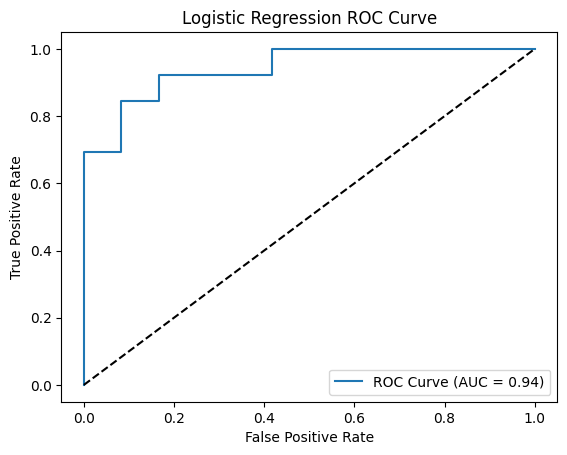

In [24]:
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "k--") # Diagonal diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()